In [1]:
import pandas as pd
import pysam
import os

# Phylogenetic Order

In [2]:
from typing import List, Optional
from Bio import Phylo

def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)
    
def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [3]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [4]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


In [9]:
goodTSPYSamples=[]
with open('/LeeLab/HPRC/chromosomeY/QC/LocationFiles/TSPY_QC_File.txt','r') as inFile:
    for line in inFile:
        goodTSPYSamples.append(line.strip())

print(len(goodTSPYSamples))

110


# Pull Sequences

In [10]:
originalDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_HPRC_CEPH-AmpliconicGenes_combined_wLiftOff_plusManualAnnotation.09302025_AllExonGenes_noDbGaP.csv").drop(columns=['Unnamed: 0'])
tspyDF=originalDF[originalDF['geneName']=='TSPY1'].copy()

In [63]:
import json
with open('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/TSPY_Plus_Flanking/TSPY_Network_Node_Colors_IDs.json', 'r') as file:
    ColorDictionary = json.load(file)

In [12]:
from Bio.Seq import Seq

In [14]:
#this code pulls the full gene plus/minus 1000 bases on the flanks
uniqueSequences={}
uniquePromoters={}
uniquePromoters2={}
folderDirectory='/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/TSPY_Plus_Flanking/'
for sample in set(tspyDF['sampleName']):

    if sample in goodTSPYSamples:

        geneDF = tspyDF[tspyDF['sampleName']==sample].copy()
    
        #with open(folderDirectory+"HPRC-HGSVC3-CEPH_v2_TSPY_genes.fasta", 'a+') as file:
        for row in geneDF.index:
    
            mySeqRealName = str(geneDF.at[row,'contig'])+":"+str(int(geneDF.at[row,'contigStart']))+"-"+str(int(geneDF.at[row,'contigEnd']))
            if ColorDictionary[mySeqRealName][1] == 'black':
                continue
            else:
                mySeqName = str(geneDF.at[row,'contig'])+":"+str(int(geneDF.at[row,'contigStart'])-2000)+"-"+str(int(geneDF.at[row,'contigEnd'])+2000)
        
                sequence1 = ''.join(pysam.faidx(assemblyDict[sample], mySeqName).split()[1:])
                if geneDF.at[row,'orientation'] == '+':
                    sequence = sequence1
                    promoterSequence=sequence[:2000]
                else:
                    sequence = str(Seq(sequence1).reverse_complement())
                    promoterSequence=sequence[:2000]
        
                if str(geneDF.at[row,'geneCompletenessInfo'])=='Full_Exon_Copy':
    
                    uniquePromoters2[mySeqRealName]=promoterSequence
                    
                    if sequence in uniqueSequences:
                        uniqueSequences[sequence].append(mySeqRealName)
            
                    else:
                        uniqueSequences[sequence]=[mySeqRealName]
            
            
                    if promoterSequence in uniquePromoters:
                        uniquePromoters[promoterSequence].append(mySeqRealName)
            
                    else:
                        uniquePromoters[promoterSequence]=[mySeqRealName]
                    
                    
                #if str(geneDF.at[row,'geneCompletenessInfo'])=='Full_Exon_Copy':
                #    file.write(">"+mySeqName+"\n")
                #    file.write(sequence+"\n")
    
        #file.close()

In [15]:
print(len(uniqueSequences))

1374


In [17]:
#with open(folderDirectory+'uniqueSequences_TPY.json', 'w') as fp:
#    json.dump(uniqueSequences, fp)

In [18]:
print(len(uniquePromoters))

396


In [19]:
#with open(folderDirectory+"HPRC-HGSVC3-CEPH_v2_TSPY_uniqueGeneSequences_Jan202026.fasta", 'a+') as file:
#    for x,names in uniqueSequences.items():
#        file.write(">"+names[0]+"\n")
#        file.write(x+"\n")
#file.close()

In [20]:
#with open(folderDirectory+"HPRC-HGSVC3-CEPH_v2_TSPY_uniquePromoterSequences_Jan202026.fasta", 'a+') as file:
#    for x,names in uniquePromoters.items():
#        file.write(">"+names[0]+"\n")
#        file.write(x+"\n")
#file.close()

In [21]:
count=1
uniquePromotersNames={}
for x in uniquePromoters.keys():
    uniquePromotersNames[x] = 'SeqPromoter:'+str(count)
    count+=1

In [22]:
from pyjaspar import jaspardb

In [26]:
import json
#with open('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/TSPY_Plus_Flanking/TSPY_Upstream_Motif_hits_Jan202026.json', 'w') as fp:
#    json.dump(promoters, fp)

In [24]:
import re
from Bio.Seq import Seq

EXACT_MODE = "iupac" 

IUPAC_REGEX = {
    "A":"A", "C":"C", "G":"G", "T":"T",
    "R":"[AG]", "Y":"[CT]", "S":"[GC]", "W":"[AT]",
    "K":"[GT]", "M":"[AC]", "B":"[CGT]", "D":"[AGT]",
    "H":"[ACT]", "V":"[ACG]", "N":"[ACGT]"
}

JASPAR = jaspardb(release="JASPAR2024")
motifs_list = JASPAR.fetch_motifs(collection="CORE", tax_group="vertebrates")

names2={}

motif_specs = []
for mot in motifs_list:
    motif_id   = mot.matrix_id or mot.name
    motif_name = mot.name
    strict     = str(mot.consensus).upper()
    iupac      = str(mot.degenerate_consensus).upper()
    mlen       = len(strict)
    names2[mot.matrix_id]=mot.name

    if EXACT_MODE == "strict":
        patt_str = strict
        patt_rc  = str(Seq(strict).reverse_complement())
        rx_fwd   = re.compile(re.escape(patt_str))
        rx_rc    = re.compile(re.escape(patt_rc))
    else:
        def iupac_to_regex(s):
            return "".join(IUPAC_REGEX.get(ch, ch) for ch in s)
        patt_str = iupac_to_regex(iupac)
        iupac_rc = str(Seq(iupac).reverse_complement())
        patt_rc  = iupac_to_regex(iupac_rc)
        rx_fwd   = re.compile(patt_str)
        rx_rc    = re.compile(patt_rc)

    motif_specs.append({
        "motif_id": motif_id,
        "motif_name": motif_name,
        "strict": strict,
        "iupac": iupac,
        "mlen": mlen,
        "rx_fwd": rx_fwd,
        "rx_rc": rx_rc
    })

promoters = {x: {'plus': [], 'minus': []} for x in uniquePromotersNames.values()}

for rec in uniquePromoters.keys():
    seq = str(Seq(rec).upper())
    L   = len(seq)
    rc  = str(Seq(seq).reverse_complement())
    pname = uniquePromotersNames[rec]

    for spec in motif_specs:
        mlen = spec["mlen"]
        for m in spec["rx_fwd"].finditer(seq):
            pos = m.start()
            match_seq = seq[pos:pos+mlen]
            promoters[pname]['plus'].append([
                pos, pos+mlen, "+",
                spec["motif_name"], spec["motif_id"],
                None,                   
                match_seq,
                spec["iupac"] if EXACT_MODE == "iupac" else spec["strict"]
            ])

        for m in spec["rx_rc"].finditer(rc):
            rc_pos = m.start()
            start  = L - (rc_pos + mlen)
            end    = start + mlen
            match_seq = rc[rc_pos:rc_pos+mlen]   
            promoters[pname]['minus'].append([
                start, end, "-",
                spec["motif_name"], spec["motif_id"],
                None,
                match_seq,
                spec["iupac"] if EXACT_MODE == "iupac" else spec["strict"]
            ])


In [25]:
rows = [
    (prom, h[3])
    for prom, orient_dict in promoters.items()
    for hits in orient_dict.values()
    for h in hits
]
df = pd.DataFrame(rows, columns=["promoter", "motif"])

countDF = (
    pd.crosstab(df["promoter"], df["motif"])
      .reindex(index=promoters.keys(), fill_value=0)
      .reindex(columns=list(set(list(names2.values()))), fill_value=0)
      .astype("int32")
)

In [38]:
from gprofiler import GProfiler
gp = GProfiler(return_dataframe=True)

Model selection (KMeans sweep):
    silhouette  calinski_harabasz  davies_bouldin
k                                               
7    0.585295         389.887003        0.893734
6    0.583137         408.628282        0.935166
5    0.565559         409.415883        0.907643
8    0.548712         363.094162        0.891675
4    0.529745         456.391791        0.757472
9    0.513628         331.079247        0.997041
2    0.243413         314.667491        0.236531
3    0.102288         222.178509        0.954957

Evaluation:
          method  silhouette  calinski_harabasz  davies_bouldin
0   KMeans(k=2)    0.243413         314.667491        0.236531
1  AggWard(k=2)    0.243413         314.667491        0.236531
cluster
0    384
1     12
Name: count, dtype: int64

Cluster 0 top motifs (lift vs global):
motif
ZEB1      1.031
FIGLA     1.031
ZNF549    1.031
RELB      1.031
HOXB6     1.031
ZNF317    1.031
TFAP2E    1.031
SOX8      1.031
Sox5      1.031
SOX18     1.031
Name: 0, dtype: 

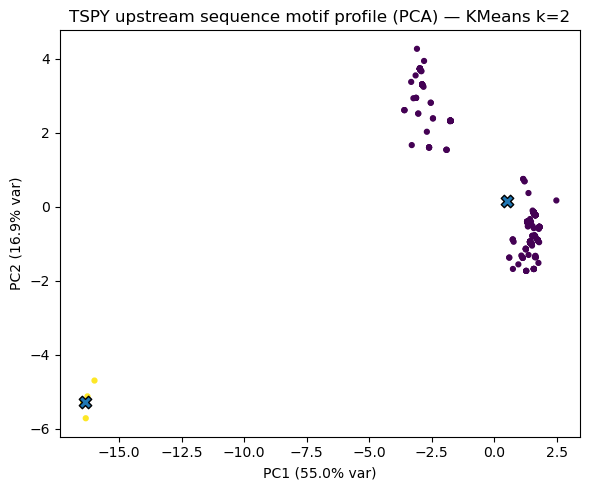

In [49]:
import numpy as np
import pandas as pd

X = countDF.loc[:, (countDF.sum(axis=0) > 0)].copy()
X_tfidf=X.copy()

from sklearn.decomposition import PCA
n_comp = min(50, X_tfidf.shape[1], max(2, X_tfidf.shape[0]-1))  # ensure ≥2
pca = PCA(n_components=n_comp, random_state=8)
X_pca = pca.fit_transform(X_tfidf)

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def try_kmeans(X_in, k_list=(2,3,4,5,6,7,8)):
    rows, models = [], {}
    for k in k_list:
        km = KMeans(n_clusters=k, n_init='auto', random_state=1)
        labels = km.fit_predict(X_in)
        s  = silhouette_score(X_in, labels, metric='cosine')
        ch = calinski_harabasz_score(X_in, labels)
        db = davies_bouldin_score(X_in, labels)
        rows.append((k, s, ch, db))
        models[k] = (km, labels)
    return pd.DataFrame(rows, columns=['k','silhouette','calinski_harabasz','davies_bouldin']).set_index('k'), models

km_scores, km_models = try_kmeans(X_pca, k_list=range(2, 10))
best_k=2
km, km_labels = km_models[best_k]

agg = AgglomerativeClustering(n_clusters=best_k, linkage='average')
agg_labels = agg.fit_predict(X_pca)

def metrics_table(X_in, labels, name):
    return pd.DataFrame({
        'method':[name],
        'silhouette':[silhouette_score(X_in, labels, metric='cosine')],
        'calinski_harabasz':[calinski_harabasz_score(X_in, labels)],
        'davies_bouldin':[davies_bouldin_score(X_in, labels)]
    })

eval_df = pd.concat([
    metrics_table(X_pca, km_labels, f'KMeans(k={best_k})'),
    metrics_table(X_pca, agg_labels, f'AggWard(k={best_k})'),
], ignore_index=True)

print("Model selection (KMeans sweep):\n", km_scores.sort_values('silhouette', ascending=False))
print("\nEvaluation:\n", eval_df)

res = countDF.copy()
res['cluster'] = km_labels
print(res['cluster'].value_counts())

def top_motifs_by_cluster(counts: pd.DataFrame, labels: np.ndarray, topn=10):
    df = counts.copy()
    df['cluster'] = labels
    grp_mean = df.groupby('cluster').mean(numeric_only=True)
    global_mean = df.drop(columns=['cluster']).mean(axis=0)
    lift = (grp_mean + 1e-9).divide(global_mean + 1e-9)
    tops = {c: lift.loc[c].sort_values(ascending=False).head(topn) for c in grp_mean.index}
    return tops

tops = top_motifs_by_cluster(countDF, km_labels, topn=10)
for c, s in tops.items():
    print(f"\nCluster {c} top motifs (lift vs global):")
    print(s.round(3))


import matplotlib.pyplot as plt

PC = X_pca[:, :2]
var = pca.explained_variance_ratio_[:2] * 100

plt.figure(figsize=(6,5))
sc = plt.scatter(PC[:,0], PC[:,1], c=km_labels, s=12)

cent2d = km.cluster_centers_[:, :2]
plt.scatter(cent2d[:,0], cent2d[:,1], marker='X', s=80, edgecolor='k')

plt.title(f"TSPY upstream sequence motif profile (PCA) — KMeans k={best_k}")
plt.xlabel(f"PC1 ({var[0]:.1f}% var)")
plt.ylabel(f"PC2 ({var[1]:.1f}% var)")
plt.tight_layout()
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/TSPY/TSPYUpstream_Kmeans_Jan202026.pdf", dpi=300, bbox_inches='tight')
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/TSPY/TSPYUpstream_Kmeans_Jan202026.jpg", dpi=300, bbox_inches='tight')
plt.show()


In [47]:
sortedPromoterDF = res.sort_values(by=['cluster']).copy()
sortedPromoterDF2 = sortedPromoterDF.drop(columns=['cluster']).copy()
sortedPromoterDF3 = sortedPromoterDF2.loc[:, (countDF.sum(axis=0) > 0)].copy()
sortedPromoterDF3_sorted = sortedPromoterDF3[sortedPromoterDF3.sum(axis=0).sort_values(ascending=False).index].copy()

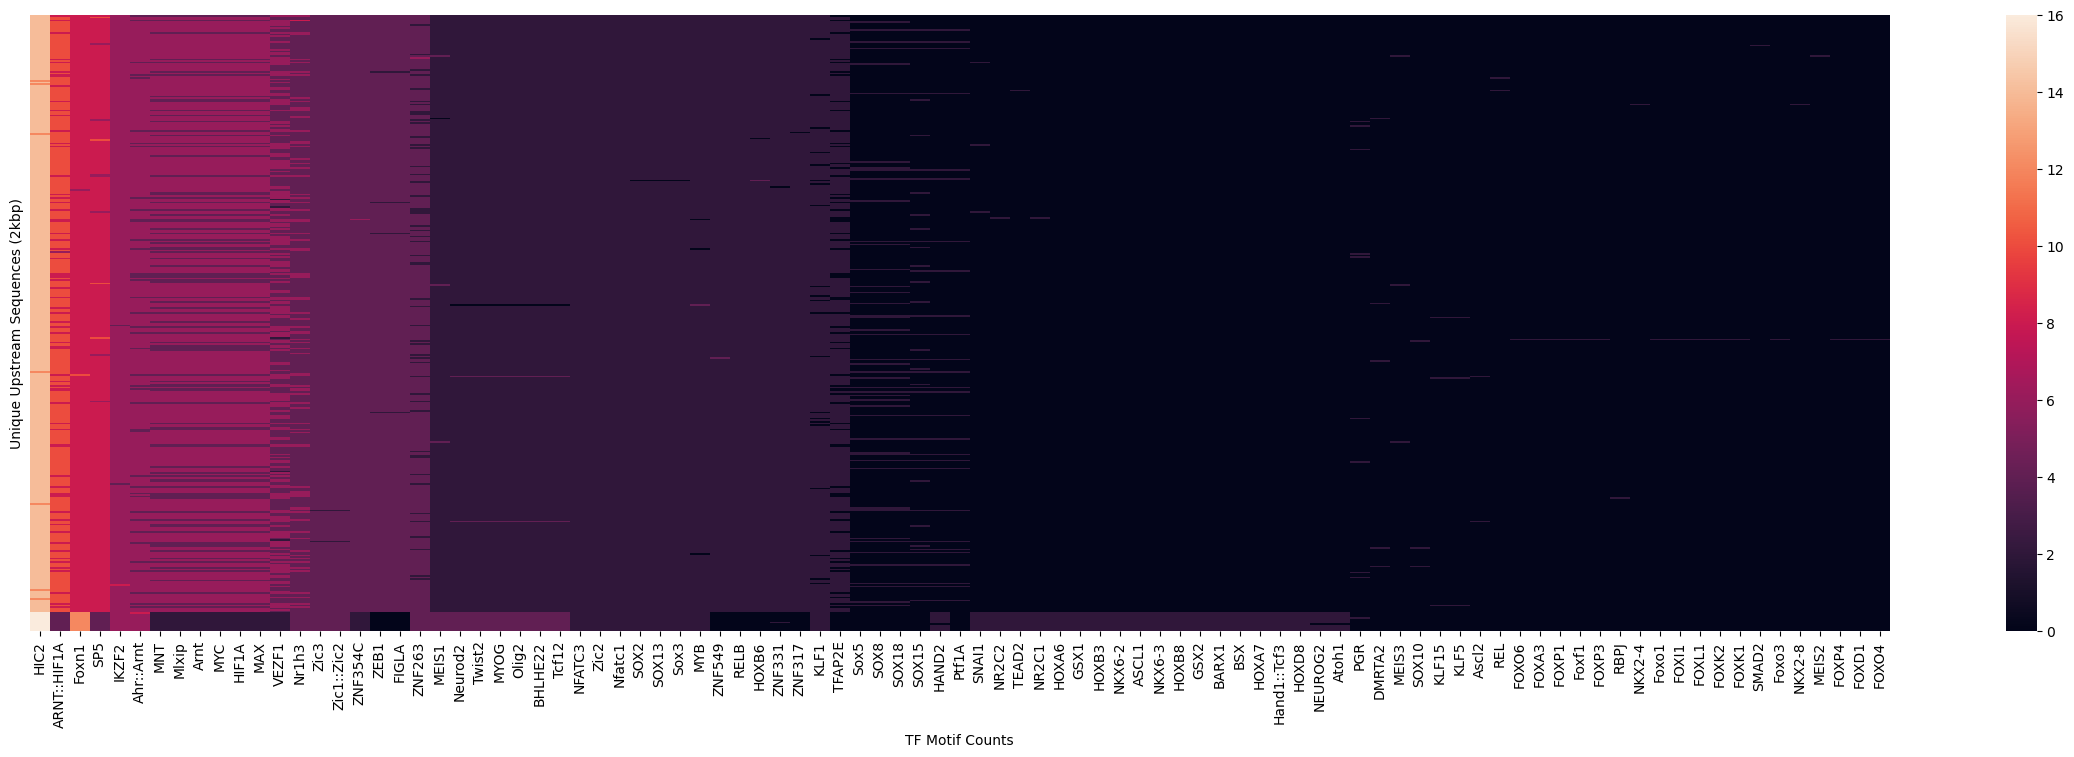

In [50]:
import seaborn as sns
plt.figure(figsize=(30, 8))
ax=sns.heatmap(sortedPromoterDF3_sorted)
ax.set_yticks([])    
plt.ylabel('Unique Upstream Sequences (2kbp)')
plt.xlabel('TF Motif Counts')
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/TSPY/Upstream_TF_Motif_Heatmap_Jan202026.pdf", dpi=300, bbox_inches='tight')
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/TSPY/Upstream_TF_Motif_Heatmap_Jan202026.jpg", dpi=300, bbox_inches='tight')
plt.show()

## Biological Differences (GO terms etc.)

In [51]:
def splitList(inputList):

    newList=[]
    for x in inputList:
        if '::' in x:
            newList.append(x.split("::")[0])
            newList.append(x.split("::")[1])
        else:
            newList.append(x)
    return(newList)

In [5]:
import mygene
print(mygene.__version__)

3.2.2


In [52]:
from mygene import MyGeneInfo
mg = MyGeneInfo()
cluster0 = splitList(tops[0].index)
cluster1 = splitList(tops[1].index)
#cluster2 = splitList(tops[2].index)
#cluster3 = splitList(tops[3].index)
q0 = mg.querymany(cluster0, scopes="symbol", fields="go", species="human")
q1 = mg.querymany(cluster1, scopes="symbol", fields="go", species="human")
#q2 = mg.querymany(cluster2, scopes="symbol", fields="go", species="human")
#q3 = mg.querymany(cluster3, scopes="symbol", fields="go", species="human")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


In [53]:
def returnTerms(records):
    terms = set()
    for rec in records:
        for item in rec.get('go', {}).get('BP', []):
            if isinstance(item, dict) and 'term' in item:
                terms.add(item['term'])
    return terms

In [54]:
#“Developmental morphogenesis / lineage specification with vascular + immune (NF-κB/TGF-β) signaling.”
#In a testis context specifically, it could reflect a somatic support / tissue remodeling state 
#(Sertoli + vasculature/immune signaling) rather than a clean “germ cell only” program—though “spermatogenesis” 
#being present means it’s not purely somatic.
returnTerms(q0)

{'Sertoli cell development',
 'T-helper 1 cell differentiation',
 'T-helper 1 type immune response',
 'adipose tissue development',
 'anatomical structure formation involved in morphogenesis',
 'angiogenesis',
 'animal organ development',
 'anterior/posterior pattern specification',
 'antigen processing and presentation',
 'astrocyte fate commitment',
 'asymmetric neuroblast division',
 'blood vessel development',
 'blood vessel endothelial cell migration',
 'canonical NF-kappaB signal transduction',
 'cartilage condensation',
 'cartilage development',
 'cell differentiation',
 'cell fate commitment',
 'cell maturation',
 'cellular response to amino acid stimulus',
 'cellular response to osmotic stress',
 'cellular response to transforming growth factor beta stimulus',
 'central nervous system development',
 'chondrocyte differentiation',
 'circadian regulation of gene expression',
 'cochlea morphogenesis',
 'developmental process',
 'embryonic camera-type eye morphogenesis',
 'embryon

In [55]:
#“Neural progenitor / forebrain patterning + oligodendrocyte/myelination, Notch-driven”.
#Notch signaling (explicitly + “positive/negative regulation of Notch”)
#Neurogenesis / neuronal fate & migration (forebrain/subpallium/telencephalon regionalization, interneuron differentiation, neuroblast fate/proliferation)
#Oligodendrocyte lineage + myelination (oligodendrocyte fate/differentiation, CNS myelination, regulation of myelination)
#Patterning morphogens (retinoic acid response; Wnt regulation; EGF response)
#Some neuroendocrine / epithelial differentiation terms sprinkled in (lung/stomach neuroendocrine cell differentiation, endocrine pancreas, adenohypophysis)
returnTerms(q1)

{'Notch signaling pathway',
 'adenohypophysis development',
 'adrenal chromaffin cell differentiation',
 'adult locomotory behavior',
 'angiogenesis',
 'animal organ development',
 'anterior/posterior pattern specification',
 'brain development',
 'carotid body glomus cell differentiation',
 'cell differentiation',
 'cell fate determination',
 'cell maturation',
 'cell-cell signaling',
 'cellular response to magnetism',
 'central nervous system development',
 'central nervous system myelination',
 'central nervous system neuron development',
 'cerebral cortex GABAergic interneuron differentiation',
 'cerebral cortex development',
 'commitment of neuronal cell to specific neuron type in forebrain',
 'digestive system development',
 'dorsal spinal cord development',
 'eating behavior',
 'embryonic skeletal system development',
 'embryonic skeletal system morphogenesis',
 'endocrine pancreas development',
 'epithelial cell differentiation',
 'forebrain dorsal/ventral pattern formation',
 

## How do the network clusters of amino acids look compared to these upstream motifs

In [64]:
copyUpstreamMotifGroups={}
for name,sequence in uniquePromoters2.items():
    copyUpstreamMotifGroups[name] = {'SequenceCluster':uniquePromotersNames[sequence], 'cluster':res.at[uniquePromotersNames[sequence], 'cluster'], 'color':ColorDictionary[name][0]}

In [65]:
clusterNetworkDF = pd.DataFrame(data=copyUpstreamMotifGroups).T

In [66]:
import collections
collections.Counter(clusterNetworkDF['cluster'])

Counter({np.int32(0): 3395, np.int32(1): 110})

In [70]:
#clusterNetworkDF.to_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/TSPY_Plus_Flanking/TSPY_Upstream_Motif_Groupings_Jan202026.csv")

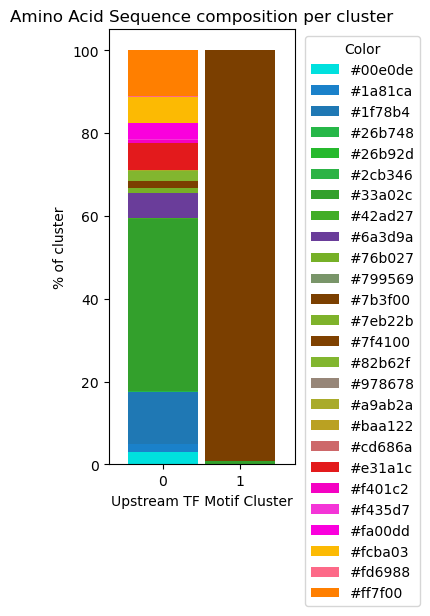

In [69]:
row_pct.plot(kind="bar", stacked=True, figsize=(4,6), width=0.9, color=row_pct.columns)
plt.ylabel("% of cluster")
plt.xticks(rotation=0)
plt.xlabel("Upstream TF Motif Cluster", rotation=0) 
plt.legend(title="Color", bbox_to_anchor=(1.02,1), loc="upper left")
plt.title("Amino Acid Sequence composition per cluster")
plt.tight_layout()
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/TSPY/Upstream_TF_Motif_wAminoAcidClusers_Jan202026.pdf", bbox_inches='tight')
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/TSPY/Upstream_TF_Motif_wAminoAcidClusers_Jan202026.jpg", dpi=300, bbox_inches='tight')
plt.show()